Данные с каггла https://www.kaggle.com/competitions/spaceship-titanic/data?select=train.csv

# Разведочный анализ, удаление пропусков, преобразование категориальных признаков

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
data = pd.read_csv("train.csv")
data.head(10)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


In [13]:
data.dtypes

PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object

In [14]:
data.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [15]:
total_count = data.shape[0]
num_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Age. Тип данных float64. Количество пустых значений 179, 2.06%.
Колонка RoomService. Тип данных float64. Количество пустых значений 181, 2.08%.
Колонка FoodCourt. Тип данных float64. Количество пустых значений 183, 2.11%.
Колонка ShoppingMall. Тип данных float64. Количество пустых значений 208, 2.39%.
Колонка Spa. Тип данных float64. Количество пустых значений 183, 2.11%.
Колонка VRDeck. Тип данных float64. Количество пустых значений 188, 2.16%.


In [16]:
cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
data[cols] = data[cols].fillna(data[cols].mean())

In [17]:
cat_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='object' or dt=='str'):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка HomePlanet. Тип данных str. Количество пустых значений 201, 2.31%.
Колонка CryoSleep. Тип данных object. Количество пустых значений 217, 2.5%.
Колонка Cabin. Тип данных str. Количество пустых значений 199, 2.29%.
Колонка Destination. Тип данных str. Количество пустых значений 182, 2.09%.
Колонка VIP. Тип данных object. Количество пустых значений 203, 2.34%.
Колонка Name. Тип данных str. Количество пустых значений 200, 2.3%.


In [18]:
categorical_cols = ['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']
for col in categorical_cols:
    if col in data.columns:
        mode_val = data[col].mode()[0]  
        data[col] = data[col].fillna(mode_val)
        print(f"Столбец '{col}' заполнен значением: {mode_val}")

Столбец 'HomePlanet' заполнен значением: Earth
Столбец 'CryoSleep' заполнен значением: False
Столбец 'Cabin' заполнен значением: G/734/S
Столбец 'Destination' заполнен значением: TRAPPIST-1e
Столбец 'VIP' заполнен значением: False
Столбец 'Name' заполнен значением: Alraium Disivering


In [19]:
data.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

In [32]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
data_encoded = data.copy()
data_encoded[['HomePlanet','Destination','Cabin']] = oe.fit_transform(data_encoded[['HomePlanet','Destination','Cabin' ]])
data_encoded = data_encoded.drop(columns =['PassengerId', 'Name', ])


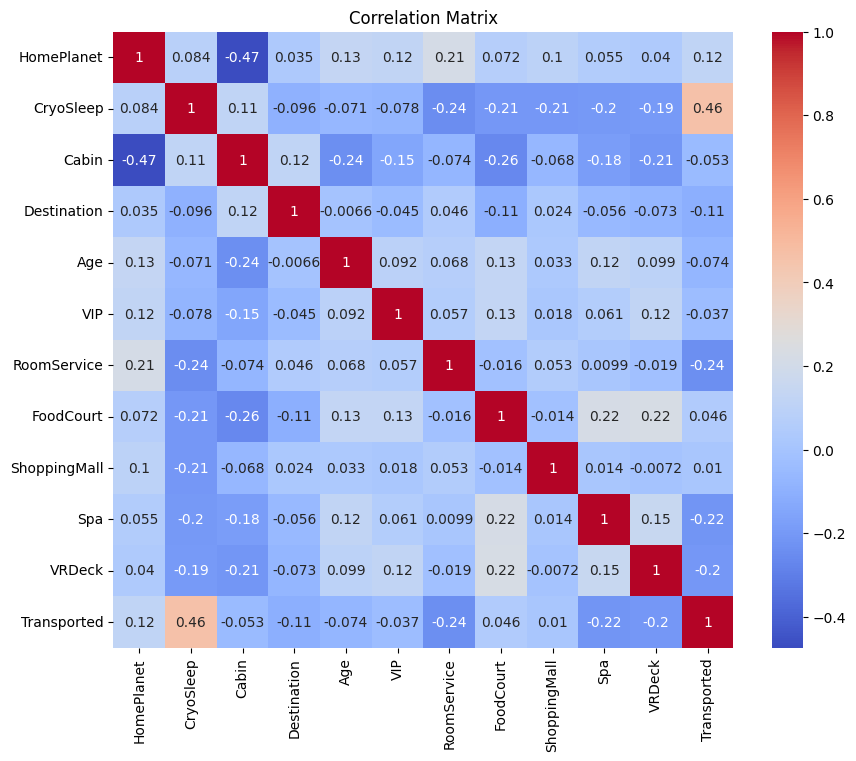

In [33]:
correlation_matrix = data_encoded.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [34]:
X = data_encoded.drop(columns=['Transported'])
y = data_encoded['Transported']

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Метод ближайших соседей с k = 5

In [99]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, recall_score, f1_score, roc_curve, roc_auc_score
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print(f"Точность: {accuracy_score(y_test, y_pred):.4f}")
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f"Precision: {precision_score(y_test, y_pred):.4f}\nRecall: {recall_score(y_test, y_pred):.4f}\nf1_score: {f1_score(y_test, y_pred):.4f}")

Точность: 0.7585
Матрица ошибок:
[[653 208]
 [212 666]]
Precision: 0.7620
Recall: 0.7585
f1_score: 0.7603


# Метод ближайших соседей с подбором гиперпараметра методом GridSearch с помощью кросс-валидации методом StratifiedKFold

In [85]:
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
n_range = np.array(range(1,30,1))
tuned_parameters = [{'n_neighbors': n_range}]
tuned_parameters

[{'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])}]

In [97]:
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    tuned_parameters,
    cv=cv_stratified,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
print(f"Лучший параметр: {grid_search.best_params_}\nЛучшая точность: {grid_search.best_score_:.4f}")

Лучший параметр: {'n_neighbors': np.int64(23)}
Лучшая точность: 0.7836


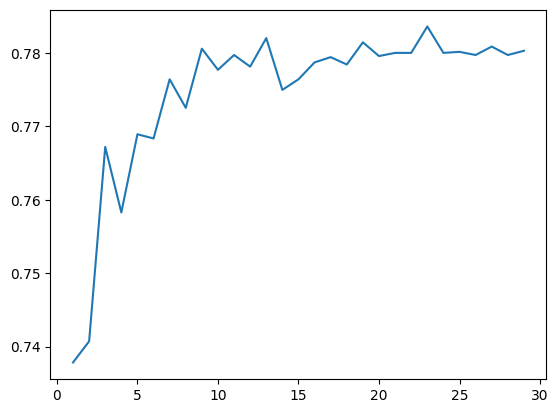

In [80]:
plt.plot(n_range, grid_search.cv_results_['mean_test_score'])

# Метод ближайших соседей с подбором гиперпараметра методом RandomSearch с помощью кросс-валидации методом KFold

In [96]:
random_search = RandomizedSearchCV(
   KNeighborsClassifier(),
    tuned_parameters,
    n_iter=30,
    cv=cv_stratified,
    scoring='accuracy',
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

print(f"Лучший параметр: {random_search.best_params_}\nЛучшая точность: {random_search.best_score_:.4f}")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 29 is smaller than n_iter=30. Running 29 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Лучший параметр: {'n_neighbors': np.int64(23)}
Лучшая точность: 0.7836


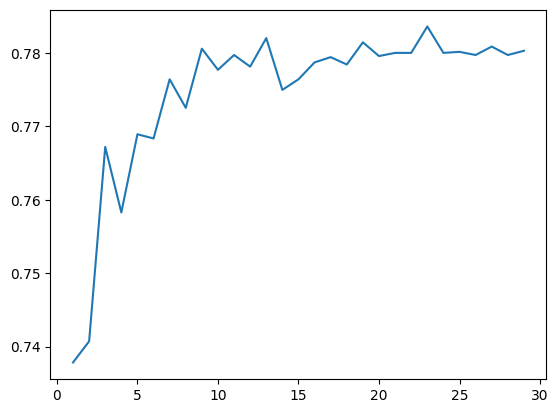

In [82]:
plt.plot(n_range, random_search.cv_results_['mean_test_score'])

In [87]:
from sklearn.model_selection import learning_curve, validation_curve
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5), scoring='accuracy'):
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(scoring)
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.3,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt

<module 'matplotlib.pyplot' from '/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/pyplot.py'>

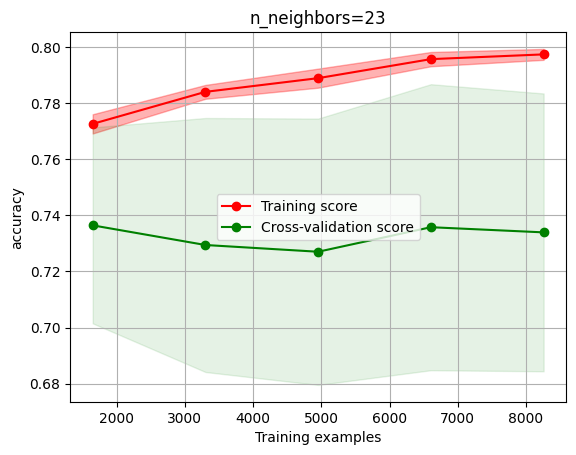

In [91]:
plot_learning_curve(grid_search.best_estimator_, 'n_neighbors=23', X, y, cv=20, train_sizes=np.linspace(.2, 1.0, 5))

In [89]:
def plot_validation_curve(estimator, title, X, y, 
                          param_name, param_range, cv, 
                          scoring='accuracy'):
                                                   
    train_scores, test_scores = validation_curve(
        estimator, X, y, param_name=param_name, param_range=param_range,
        cv=cv, scoring=scoring, n_jobs=1)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.title(title)
    plt.xlabel(param_name)
    plt.ylabel(str(scoring))
    plt.ylim(0.0, 1.1)
    lw = 2
    plt.plot(param_range, train_scores_mean, label="Training score",
                 color="darkorange", lw=lw)
    plt.fill_between(param_range, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.4,
                     color="darkorange", lw=lw)
    plt.plot(param_range, test_scores_mean, label="Cross-validation score",
                 color="navy", lw=lw)
    plt.fill_between(param_range, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.2,
                     color="navy", lw=lw)
    plt.legend(loc="best")
    return plt

<module 'matplotlib.pyplot' from '/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/pyplot.py'>

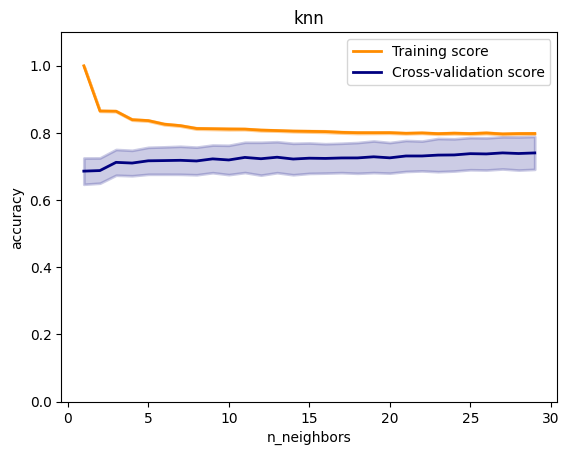

In [92]:
plot_validation_curve(grid_search.best_estimator_, 'knn', 
                      X, y, 
                      param_name='n_neighbors', param_range=n_range, 
                      cv=20, scoring="accuracy")

Точность: 0.7585
Матрица ошибок:
[[653 208]
 [212 666]]
Precision: 0.7620
Recall: 0.7585
f1_score: 0.7603
ROC-AUC: 0.8435


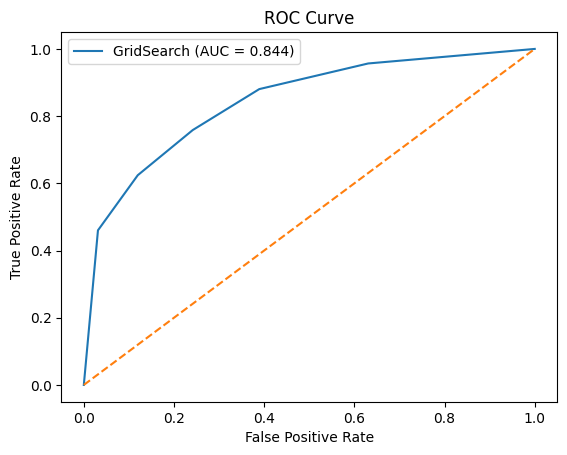

In [106]:
y_pred = knn.predict(X_test_scaled)
y_proba = knn.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Точность: {accuracy_score(y_test, y_pred):.4f}")
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f"Precision: {precision_score(y_test, y_pred):.4f}\nRecall: {recall_score(y_test, y_pred):.4f}\nf1_score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f'GridSearch (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')  
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


Точность: 0.7930
Матрица ошибок:
[[669 192]
 [168 710]]
Precision: 0.7871
Recall: 0.8087
f1_score: 0.7978
ROC-AUC: 0.8738


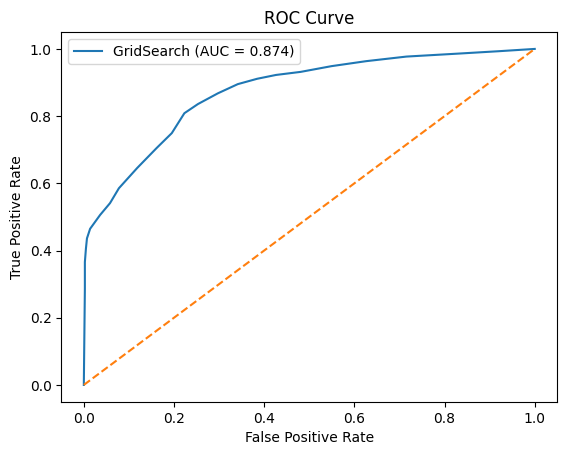

In [105]:
best_knn_grid = grid_search.best_estimator_
y_pred_grid= best_knn_grid.predict(X_test_scaled)
y_proba_grid = best_knn_grid.predict_proba(X_test_scaled)[:, 1]
fpr_grid, tpr_grid, _ = roc_curve(y_test, y_proba_grid)
roc_auc_grid = roc_auc_score(y_test, y_proba_grid)

print(f"Точность: {accuracy_score(y_test, y_pred_grid):.4f}")
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred_grid))
print(f"Precision: {precision_score(y_test, y_pred_grid):.4f}\nRecall: {recall_score(y_test, y_pred_grid):.4f}\nf1_score: {f1_score(y_test, y_pred_grid):.4f}")
print(f"ROC-AUC: {roc_auc_grid:.4f}")

plt.figure()
plt.plot(fpr_grid, tpr_grid, label=f'GridSearch (AUC = {roc_auc_grid:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')  
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()